# Benchmarking on Graviton 4

On Graviton 4 (Neoverse V2), AWS `c8g.metal-24xl`.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

matplotlib.rcParams.update({"axes.spines.right": False, "axes.spines.top": False, "legend.frameon": False})

## Memory bandwidth

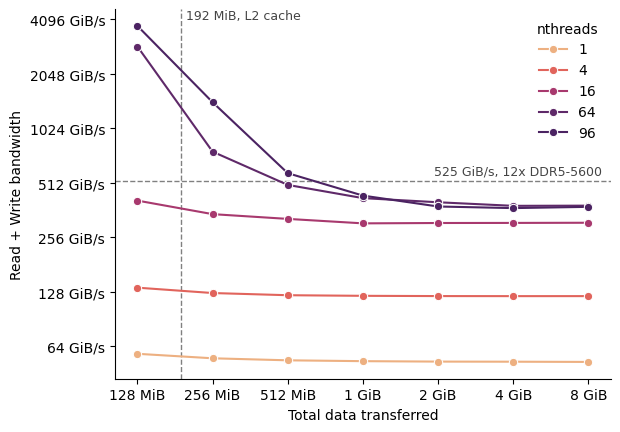

In [ ]:
# /dev run benchmark -- _memory_bandwidth --json > bandwidth.jsonl
df = pd.read_json("data/20251015-bandwidth.jsonl", lines=True)

ax = sns.lineplot(data=df, y="transfer_gib_s", x="byte_count", hue="nthreads", hue_norm=matplotlib.colors.LogNorm(), palette="flare", marker="o")

theoretical_bw_gib_s = 12 * 5600 * 8 / 1024  # 12 channels, 5600 MT/s, 8 bytes per transfer, in GiB/s
ax.axhline(theoretical_bw_gib_s, color="gray", linestyle="--", zorder=0, lw=1)
ax.annotate(f"{theoretical_bw_gib_s:.0f} GiB/s, 12x DDR5-5600",
            xy=(ax.get_xlim()[1], theoretical_bw_gib_s), xytext=(6, 2), textcoords="offset points", va="bottom", ha="right", fontsize=9, color="#444")
total_l2 = 96 * 2 * 1024**2  # 96 cores, 2 MiB per core
ax.axvline(total_l2, color="gray", linestyle="--", zorder=0, lw=1)
ax.annotate(f"{total_l2/1024**2:.0f} MiB, L2 cache",
            xy=(total_l2, ax.get_ylim()[1]), xytext=(3, 0), textcoords="offset points", va="bottom", ha="left", fontsize=9, color="#444")

ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f"{x/1024**3:.0f} GiB" if x >= 1024**3 else f"{x/1024**2:.0f} MiB"))
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda y, _: f"{y:.0f} GiB/s"))
ax.set_xlabel("Total data transferred")
ax.set_ylabel("Read + Write bandwidth");

## Dot product

Graviton4/NeoverseV2 (see [Arm Neoverse V2 Software Optimisation Guide](https://documentation-service.arm.com/static/668bc0a369e89f01e39c4668?token=) and [A64 SIMD instructions](https://developer.arm.com/documentation/ddi0602/2025-09/SIMD-FP-Instructions)).

| Instruction | Shape | MACs | Throughput | Latency |
| --- | --- | --- | --- | --- |
| `fmla` | `4*1x1x1` | 4 | 4 | 4(2) |
| `bfdot` | `4*1x2x1` | 8 | 4 | 5(3) |
| `bfmmla` | `1*2x4x2` | 16 | 4 | 6(4) |
| `smmla` | `1*2x8x2` | 32 | 4 | 3(1) |

32 kiB data cache per core.

A 16x16x16 dot product in FP32, with `__restrict__` pointers, generates [`fmla .4s`](https://developer.arm.com/documentation/dui0801/l/A64-SIMD-Vector-Instructions/FMLA--vector---A64-) instructions, with `ldr`, `ldur` and `ldp`.

In [14]:
# ./dev run benchmark -- _dot_inst_throughput
# (note: speed can vary, especially smmla, bfmmla)

for inst, macs, tput, observed in [
    ("fmla", 4, 4, 44.6),
    ("bfdot", 8, 4, 62.7),
    ("bfmmla", 16, 4, 115),
    ("smmla", 32, 4, 357),
]:
    theoretical_macs = 2.8e9 * tput * macs
    print(f"{inst:>8}: {theoretical_macs/1e9:>6.2f} GMAC/s/core  observed: {observed*1e9/theoretical_macs*100:>5.1f}% of theoretical")

    fmla:  44.80 GMAC/s/core  observed:  99.6% of theoretical
   bfdot:  89.60 GMAC/s/core  observed:  70.0% of theoretical
  bfmmla: 179.20 GMAC/s/core  observed:  64.2% of theoretical
   smmla: 358.40 GMAC/s/core  observed:  99.6% of theoretical


## Note - eventual target platform (Android)

Pixel 8a: 1x3.0 GHz Cortex-X3 & 4x2.45 GHz Cortex-A715 & 4x2.15 GHz Cortex-A510.

- Cortex-X3 ([software guide](https://developer.arm.com/documentation/PJDOC-466751330-590747/latest))
- Cortex-A715 ([software guide](https://developer.arm.com/documentation/PJDOC-466751330-556347/latest))
- Cortex-A510 ([software guide](https://developer.arm.com/documentation/PJ02607EXP-1901056752-266/latest))